In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

# Load processed data from preprocessing.ipynb
edges = pd.read_csv("../data/preprocessed/processed_edges.csv")
nodes = pd.read_csv("../data/preprocessed/processed_nodes.csv")

print(edges.shape, nodes.shape)
edges.head()


(3732460, 3) (139255, 4)


,pre,post,weight
0,720575940596125868,720575940605825666,6
1,720575940596125868,720575940608552405,6
2,720575940596125868,720575940609975854,5
3,720575940596125868,720575940613059993,9
4,720575940596125868,720575940613599129,6


In [4]:
# Compute out-strength (sum of synapse weights)
out_strength = (
    edges.groupby("pre")["weight"]
    .sum()
    .sort_values(ascending=False)
)

out_strength.head()


pre
720575940626979621    110708
720575940628908548    109699
720575940624547622     85998
720575940613583001     74963
720575940625952755     46159
Name: weight, dtype: int64

In [5]:
TOP_N = 1000  

top_nodes = set(out_strength.head(TOP_N).index)
len(top_nodes)


1000

In [6]:
edges_sub = edges[
    edges["pre"].isin(top_nodes) &
    edges["post"].isin(top_nodes)
].copy()

edges_sub.shape


(28675, 3)

In [7]:
G= nx.DiGraph()

for _, row in edges_sub.iterrows():
    G.add_edge(int(row.pre), int(row.post), weight=int(row.weight))

# Attach node metadata
for _, row in nodes.iterrows():
    nid = int(row.id)
    if nid in G:
        for col in nodes.columns:
            if col != "id":
                G.nodes[nid][col] = row[col]

print(f"Subgraph G created: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


Subgraph G created: 1000 nodes, 28675 edges


In [8]:
edges_sub.shape
edges_sub.head()

,pre,post,weight
4830,720575940603464672,720575940605758142,32
4837,720575940603464672,720575940606722249,54
4857,720575940603464672,720575940609282825,41
4859,720575940603464672,720575940610161091,43
4865,720575940603464672,720575940610530606,5


In [9]:
#BASIC NETWORK PROPERTIES
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
reciprocity = nx.reciprocity(G)

# Largest components
largest_wcc = max(nx.weakly_connected_components(G), key=len)
largest_scc = max(nx.strongly_connected_components(G), key=len)

print("Nodes:", num_nodes)
print("Edges:", num_edges)
print("Density:", density)
print("Reciprocity:", reciprocity)
print("Largest WCC size:", len(largest_wcc))
print("Largest SCC size:", len(largest_scc))


Nodes: 1000
Edges: 28675
Density: 0.028703703703703703
Reciprocity: 0.581482127288579
Largest WCC size: 1000
Largest SCC size: 976


In [10]:
import pickle

with open("../data/preprocessed/subgraph.pkl", "wb") as f:
    pickle.dump(G, f)

print("Saved subgraph to ../data/preprocessed/subgraph.pkl")


Saved subgraph to ../data/preprocessed/subgraph.pkl


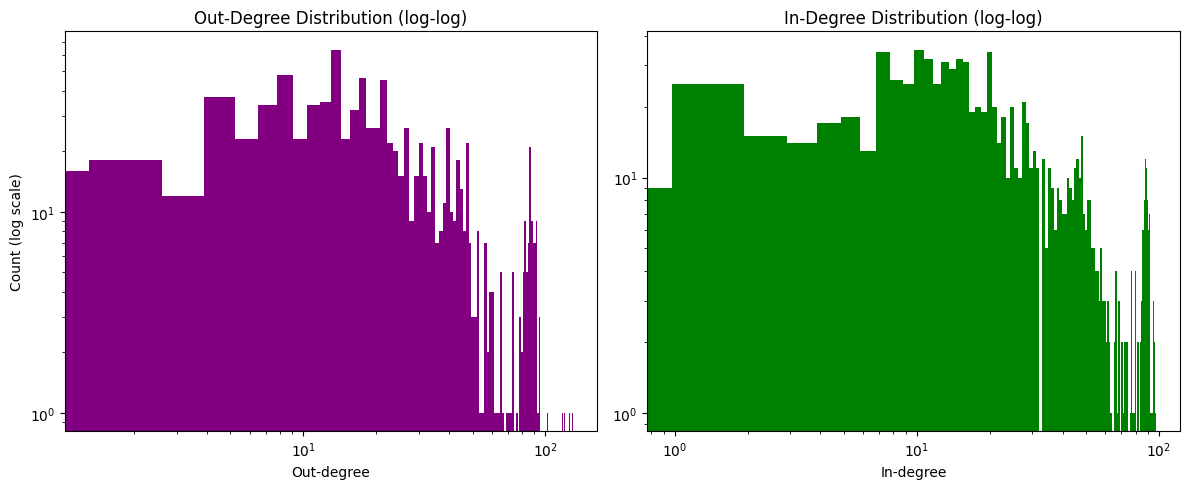

In [11]:
#DEGREE DISTRIBUTIONS
out_deg = [d for _, d in G.out_degree()]
in_deg  = [d for _, d in G.in_degree()]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(out_deg, bins=100, color="purple", log=True)
plt.xscale("log")
plt.title("Out-Degree Distribution (log-log)")
plt.xlabel("Out-degree")
plt.ylabel("Count (log scale)")

plt.subplot(1,2,2)
plt.hist(in_deg, bins=100, color="green", log=True)
plt.xscale("log")
plt.title("In-Degree Distribution (log-log)")
plt.xlabel("In-degree")

plt.tight_layout()
plt.show()



In [12]:
#Degree Centrality
deg_cent = nx.degree_centrality(G)


In [13]:
#Closeness Centrality
closeness = nx.closeness_centrality(G)



In [14]:
#Betweennes Centrality
G_dist = G.copy()
for u, v, d in G_dist.edges(data=True):
    d["dist"] = 1 / (d["weight"] + 1e-9)

betweenness = nx.betweenness_centrality(G_dist, weight="dist")


In [15]:
#Eigenvector_centrality
eig = nx.eigenvector_centrality(G.to_undirected(), max_iter=500, weight="weight")


In [16]:
#Page rank
pagerank = nx.pagerank(G, weight="weight")


In [17]:
cent_df = pd.DataFrame({
    "id": list(G.nodes()),
    "name": [G.nodes[n].get("name") for n in G.nodes()],
    "degree_centrality": [deg_cent[n] for n in G.nodes()],
    "closeness": [closeness[n] for n in G.nodes()],
    "betweenness": [betweenness[n] for n in G.nodes()],
    "eigenvector": [eig[n] for n in G.nodes()],
    "pagerank": [pagerank[n] for n in G.nodes()],
})

cent_df.head()


,id,name,degree_centrality,closeness,betweenness,eigenvector,pagerank
0,720575940603464672,AL.LH.7,0.103103,0.293342,0.012181,0.000071,0.000821
1,720575940605758142,AL.14,0.178178,0.301209,0.001826,0.000239,0.001955
2,720575940606722249,AL.45,0.182182,0.311880,0.000995,0.000171,0.001816
3,720575940609282825,AL.3,0.174174,0.316323,0.022744,0.000224,0.001811
4,720575940610161091,AL.80,0.175175,0.305828,0.000033,0.000135,0.001672


In [18]:
print("Top 10 by eigenvector centrality:")
display(cent_df.sort_values("eigenvector", ascending=False).head(10))

print("Top 10 by betweenness:")
display(cent_df.sort_values("betweenness", ascending=False).head(10))

print("Top 10 by PageRank:")
display(cent_df.sort_values("pagerank", ascending=False).head(10))


Top 10 by eigenvector centrality:


,id,name,degree_centrality,closeness,betweenness,eigenvector,pagerank
499,720575940628307026,LOP.2,0.060060,0.316836,0.040067,0.518426,0.005433
746,720575940627190556,LOP.8,0.036036,0.286294,0.034830,0.436355,0.001114
749,720575940632504874,LOP.7,0.035035,0.288151,0.001007,0.402993,0.001145
433,720575940632427603,LOP.IPS.1,0.044044,0.283717,0.027169,0.321649,0.000876
750,720575940634612194,LOP.3,0.036036,0.286546,0.035939,0.271500,0.003417
747,720575940627706398,LOP.10,0.039039,0.310690,0.000208,0.254748,0.002288
751,720575940639209956,LOP.9,0.043043,0.295560,0.001700,0.163796,0.002521
830,720575940613091290,LOP.26,0.033033,0.288151,0.004658,0.149998,0.000508
426,720575940627348617,LOP.23,0.030030,0.260914,0.006691,0.146579,0.000713
261,720575940617613398,LOP.17,0.032032,0.290983,0.000000,0.093332,0.000801


Top 10 by betweenness:


,id,name,degree_centrality,closeness,betweenness,eigenvector,pagerank
8,720575940613583001,MB_ML.MB_CA.1,0.127127,0.328223,0.165470,0.000058,0.002833
594,720575940619623407,VES.AVLP.1,0.046046,0.349596,0.099231,0.000103,0.000554
57,720575940609258850,PVLP.AVLP.3,0.078078,0.342850,0.096080,0.000923,0.003020
129,720575940624547622,MB_ML.1,0.122122,0.318904,0.085595,0.000085,0.002135
77,720575940625102224,AVLP.2,0.148148,0.370543,0.085342,0.000670,0.003808
145,720575940635945919,AL.18,0.162162,0.296997,0.070845,0.000368,0.002768
849,720575940625934094,MB_ML.3,0.027027,0.282160,0.070710,0.000023,0.000993
313,720575940630085583,LAL.3,0.047047,0.339986,0.068545,0.000141,0.002703
10,720575940614956072,AL.17,0.173173,0.298176,0.067113,0.000225,0.003078
53,720575940604088288,AVLP.6,0.126126,0.371247,0.063050,0.000614,0.004202


Top 10 by PageRank:


,id,name,degree_centrality,closeness,betweenness,eigenvector,pagerank
614,720575940618554041,ME.4,0.031031,0.286882,0.007675,3.458735e-04,0.006217
900,720575940632825913,FB.77,0.013013,0.270940,0.002991,1.200179e-05,0.005702
499,720575940628307026,LOP.2,0.060060,0.316836,0.040067,5.184263e-01,0.005433
465,720575940629513222,LOP.4,0.056056,0.313783,0.042992,8.602694e-02,0.004930
223,720575940623113752,AVLP.16,0.146146,0.379170,0.015266,1.086056e-03,0.004859
87,720575940629513478,AVLP.14,0.144144,0.387285,0.015850,1.218665e-03,0.004436
572,720575940613686698,ME.5,0.029029,0.292990,0.005021,6.125991e-04,0.004310
506,720575940611563310,ME.39072,0.049049,0.314896,0.020936,3.908189e-03,0.004261
53,720575940604088288,AVLP.6,0.126126,0.371247,0.063050,6.140455e-04,0.004202
689,720575940643867296,GNG.69,0.031031,0.244709,0.006039,2.273628e-07,0.004011


In [19]:
#Louvain
from networkx.algorithms.community import louvain_communities

communities = louvain_communities(G, weight="weight", resolution=1)

print("Number of communities:", len(communities))

# Assign community id to each node
partition = {}
for cid, community in enumerate(communities):
    for node in community:
        partition[node] = cid

nx.set_node_attributes(G, partition, "louvain")

# Compute modularity
from networkx.algorithms.community.quality import modularity
mod = modularity(G.to_undirected(), communities, weight="weight")

print("Modularity:", mod)



Number of communities: 11
Modularity: 0.6953929956376055


In [20]:
#label propragation
from networkx.algorithms.community import label_propagation_communities

lp_comms = list(label_propagation_communities(G.to_undirected()))
print(len(lp_comms), "label propagation communities found")



5 label propagation communities found


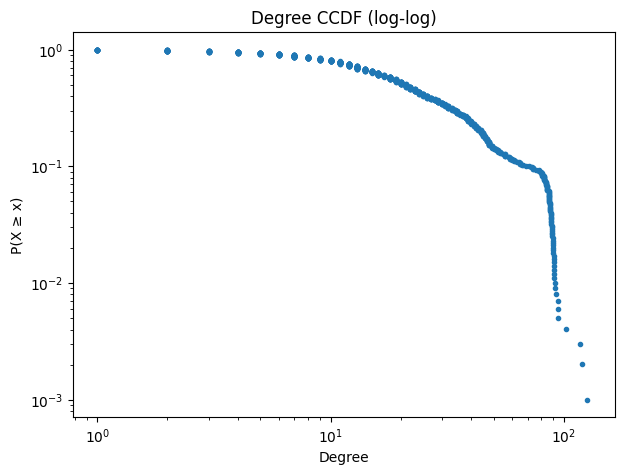

In [21]:
#Scale Free Analysis


degree_vals = np.array(out_deg)
degree_vals = degree_vals[degree_vals > 0]

sorted_vals = np.sort(degree_vals)
yvals = 1 - np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

plt.figure(figsize=(7,5))
plt.loglog(sorted_vals, yvals, marker='.', linestyle='none')
plt.xlabel("Degree")
plt.ylabel("P(X ≥ x)")
plt.title("Degree CCDF (log-log)")
plt.show()


In [22]:
cent_df.to_csv("../data/preprocessed/node_centralities.csv", index=False)
